In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm
from matplotlib import patches
import mplhep as hep
import os
from tqdm import tqdm
import ipywidgets as widget
import xsec
import itertools

Welcome to JupyROOT 6.26/08


In [2]:
ROOT.gInterpreter.Declare("""
float xsec_weight( float norm ){
    return norm;
}
""")

True

In [3]:
ROOT.gInterpreter.Declare("""
float MTW_MET( float MET, float MTW, float scale ){
    return MET + scale * MTW;
}
""")

True

In [4]:
lumitext = {
    "2016APV": "($19.52\ \mathrm{fb^{-1}}$)",
    "2016": "($16.81\ \mathrm{fb^{-1}}$)",
    "2017": "($41.48\ \mathrm{fb^{-1}}$)",
    "2018": "($59.83\ \mathrm{fb^{-1}}$)"
}
year = "2018"
rPath = "root://brux30.hep.brown.edu:1094//store/user/dali/"
rDir = rPath + "FWLJMET106XUL_singleLep{}UL_RunIISummer20_3t_step3/nominal/".format( year )
nTree = "ljmet"
fDATA = [
    #"SingleElectron_hadd.root",
    "EGamma_hadd.root",
    "SingleMuon_hadd.root"
]
fSIG = [
    "TTTJ_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
    "TTTW_TuneCP5_13TeV-madgraph-pythia8_hadd.root"
]
fBKG = {
    "TTBAR": [
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root",
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root",
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_ttbb_hadd.root",
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_ttcc_hadd.root",
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_ttjj_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_ttbb_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_ttcc_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_ttjj_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttbb_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttcc_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttjj_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_tt1b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_tt2b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttbb_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttcc_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_1_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_2_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_3_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_4_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_5_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_6_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_7_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_8_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_9_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_10_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_tt1b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_tt2b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttbb_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttcc_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttjj_hadd.root",
    ],
    "TOP": [
        "ST_s-channel_4f_leptonDecays_TuneCP5_13TeV-amcatnlo-pythia8_hadd.root",
        "ST_t-channel_top_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8_hadd.root",
        "ST_t-channel_antitop_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8_hadd.root",
        "ST_tW_top_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8_hadd.root",
        "ST_tW_antitop_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8_hadd.root",
        #"TTTT_TuneCP5_13TeV-amcatnlo-pythia8_hadd.root",
        "TTTT_TuneCP5_13TeV-amcatnlo-pythia8_1_hadd.root",
        "TTTT_TuneCP5_13TeV-amcatnlo-pythia8_2_hadd.root",
        "TTTT_TuneCP5_13TeV-amcatnlo-pythia8_3_hadd.root",
        "TTHH_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
        "TTWH_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
        "TTWW_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
        "TTWZ_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
        "TTZH_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
        "TTZZ_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
        "TTZToLLNuNu_M-10_TuneCP5_13TeV-amcatnlo-pythia8_hadd.root",
        "TTWJetsToQQ_TuneCP5_13TeV-amcatnloFXFX-madspin-pythia8_hadd.root", 
        "TTWJetsToLNu_TuneCP5_13TeV-amcatnloFXFX-madspin-pythia8_hadd.root",
        "TTZToLL_M-1to10_TuneCP5_13TeV-amcatnlo-pythia8_hadd.root",
    ],
    "TTH": [
        "ttHTobb_M125_TuneCP5_13TeV-powheg-pythia8_hadd.root",
        "ttHToNonbb_M125_TuneCP5_13TeV-powheg-pythia8_hadd.root",
    ],
    "EWK": [
        "WW_TuneCP5_13TeV-pythia8_hadd.root",
        "WZ_TuneCP5_13TeV-pythia8_hadd.root",
        "ZZ_TuneCP5_13TeV-pythia8_hadd.root",
        "DYJetsToLL_M-50_HT-200to400_TuneCP5_PSweights_13TeV-madgraphMLM-pythia8_hadd.root",
        "DYJetsToLL_M-50_HT-400to600_TuneCP5_PSweights_13TeV-madgraphMLM-pythia8_hadd.root",
        "DYJetsToLL_M-50_HT-600to800_TuneCP5_PSweights_13TeV-madgraphMLM-pythia8_hadd.root",
        "DYJetsToLL_M-50_HT-800to1200_TuneCP5_PSweights_13TeV-madgraphMLM-pythia8_hadd.root",
        "DYJetsToLL_M-50_HT-1200to2500_TuneCP5_PSweights_13TeV-madgraphMLM-pythia8_hadd.root",
        "DYJetsToLL_M-50_HT-2500toInf_TuneCP5_PSweights_13TeV-madgraphMLM-pythia8_hadd.root",
        "WJetsToLNu_HT-200To400_TuneCP5_13TeV-madgraphMLM-pythia8_hadd.root",
        "WJetsToLNu_HT-400To600_TuneCP5_13TeV-madgraphMLM-pythia8_hadd.root",
        "WJetsToLNu_HT-600To800_TuneCP5_13TeV-madgraphMLM-pythia8_hadd.root",
        "WJetsToLNu_HT-800To1200_TuneCP5_13TeV-madgraphMLM-pythia8_hadd.root",
        "WJetsToLNu_HT-1200To2500_TuneCP5_13TeV-madgraphMLM-pythia8_hadd.root",
        "WJetsToLNu_HT-2500ToInf_TuneCP5_13TeV-madgraphMLM-pythia8_hadd.root",
    ],
    "QCD": [
        "QCD_HT200to300_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
        "QCD_HT300to500_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
        "QCD_HT500to700_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
        "QCD_HT700to1000_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
        "QCD_HT1000to1500_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
        "QCD_HT1500to2000_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
        "QCD_HT2000toInf_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
    ],   
}

In [5]:
fBase = "DataPastTriggerX == 1 && MCPastTriggerX == 1"
scaleMTW = 0.667
variables = [
    "NJets_JetSubCalc",
    "NJetsCSV_JetSubCalc",
    "NresolvedTops1pFake",
    "AK4HT",
    "minDR_lepJet",
    "corr_met_MultiLepCalc",
    "MT_lepMet",
    "DNN_1to20_3t",
    "DNN_1to40_3t"
]

rDF = { "DATA": {}, "SIG": {}, "BKG": {} }
print( "Loading data:" )
for f in tqdm( fDATA ):
    rDF["DATA"][f] = ROOT.RDataFrame( nTree, rDir + f ).Filter( fBase ).Define( "MTW_MET", "MTW_MET( corr_met_MultiLepCalc, MT_lepMet, {} )".format( scaleMTW ) ).AsNumpy( columns = variables + [ "MTW_MET" ] )
print( "Loading signal:" )
for f in tqdm( fSIG ):
    rDF_ = ROOT.RDataFrame( nTree, rDir + f ).Filter( fBase ).Define( "weight", "xsec_weight( {} )".format( xsec.norm[f] ) ).Define( "MTW_MET", "MTW_MET( corr_met_MultiLepCalc, MT_lepMet, {} )".format( scaleMTW ) )
    rDF["SIG"][f] = rDF_.AsNumpy( columns = variables + [ "weight", "MTW_MET" ] )
for g in fBKG:
    rDF["BKG"][g] = {}
    print( "Loading background group: " + g )
    for f in tqdm( fBKG[g] ):
        rDF_ = ROOT.RDataFrame( nTree, rDir + f ).Filter( fBase ).Define( "weight", "xsec_weight( {} )".format( xsec.norm[f] ) ).Define( "MTW_MET", "MTW_MET( corr_met_MultiLepCalc, MT_lepMet, {} )".format( scaleMTW ) )
        rDF["BKG"][g][f] = rDF_.AsNumpy( columns = variables + [ "weight", "MTW_MET" ] )

Loading data:


100%|██████████| 2/2 [00:13<00:00,  6.91s/it]


Loading signal:


100%|██████████| 2/2 [00:03<00:00,  1.61s/it]


Loading background group: TTBAR


...

100%|██████████| 2/2 [00:08<00:00,  4.06s/it]


Loading background group: EWK


100%|██████████| 15/15 [00:41<00:00,  2.78s/it]


Loading background group: QCD


100%|██████████| 7/7 [00:09<00:00,  1.41s/it]


In [7]:
def get_sensitivity( N, M ):
    if N + M == 0: return 0
    return N / np.sqrt( N + M )

def get_ratio_err( x, xerr, y, yerr ):
    return np.sqrt( ( yerr * x / y**2 )**2 + ( xerr / y )**2 )

def get_efficiency_err(N,K):
    n = max(N,K)
    k = min(N,K)
    return np.sqrt( ( (k+1)*(k+2) ) / ( (n+2)*(n+3) ) ) - ( (k+1)**2 / (n+2)**2  )

In [8]:
vPlot = widget.Dropdown( options = variables + [ "MTW_MET" ] )
vPlot

Dropdown(options=('NJets_JetSubCalc', 'NJetsCSV_JetSubCalc', 'NresolvedTops1pFake', 'AK4HT', 'minDR_lepJet', '…

In [9]:
cuts = {
    "NJets_JetSubCalc": 6.,
    "NJetsCSV_JetSubCalc": 2.,
    "NresolvedTops1pFake": 0.,
    "DNN_1to20_3t": 0.,
    "DNN_1to40_3t": 0.2,
    "minDR_lepJet": 0.2,
    "AK4HT": 390.
}

rDF_tot = {}
rDF_weights = {}

for g in tqdm( rDF ):
    rDF_tot[ "TOTAL " + g ] = np.array([])
    if g != "DATA":
        rDF_weights[ "TOTAL " + g ] = np.array([])
    if g in [ "DATA", "SIG" ]:
        for f in rDF[ g ]:
            mask = None
            for cut in cuts:
                try: mask &= ( rDF[ g ][ f ][ cut ] >= cuts[ cut ] ) 
                except: mask = ( rDF[ g ][ f ][ cut ] >= cuts[ cut ] ) 
            rDF_tot[ "TOTAL " + g ] = np.concatenate( ( rDF_tot[ "TOTAL " + g ], rDF[ g ][ f ][ vPlot.value ][ mask ] ) )
            if g != "DATA":
                rDF_weights[ "TOTAL " + g ] = np.concatenate( ( rDF_weights[ "TOTAL " + g ], rDF[ g ][ f ][ "weight" ][ mask ] ) )
    else:
        for sg in rDF[ g ]:
            rDF_tot[ "TOTAL " + sg ] = np.array([])
            rDF_weights[ "TOTAL " + sg ] = np.array([])
            for f in rDF[ g ][ sg ]:
                mask = None
                for cut in cuts:
                    try: mask &= ( rDF[ g ][ sg ][ f ][ cut ] >= cuts[ cut ] ) 
                    except: mask = ( rDF[ g ][ sg ][ f ][ cut ] >= cuts[ cut ] )
                rDF_tot[ "TOTAL " + sg ] = np.concatenate( ( rDF_tot[ "TOTAL " + sg ], rDF[ g ][ sg ][ f ][ vPlot.value ][ mask ] ) )
                rDF_tot[ "TOTAL " + g ] = np.concatenate( ( rDF_tot[ "TOTAL " + g ], rDF[ g ][ sg ][ f ][ vPlot.value ][ mask ] ) )
                rDF_weights[ "TOTAL " + sg ] = np.concatenate( ( rDF_weights[ "TOTAL " + sg ], rDF[ g ][ sg ][ f ][ "weight" ][ mask ] ) )
                rDF_weights[ "TOTAL " + g ] = np.concatenate( ( rDF_weights[ "TOTAL " + g ], rDF[ g ][ sg ][ f ][ "weight" ][ mask ] ) )

100%|██████████| 3/3 [00:10<00:00,  3.43s/it]


In [10]:
vBins = {
    "NJets_JetSubCalc": np.linspace( 2, 12, 11 ),
    "NJetsCSV_JetSubCalc": np.linspace( 0, 7, 8 ),
    "NresolvedTops1pFake": np.linspace( 0, 4, 5 ),
    "AK4HT": np.linspace( 300, 600, 16 ),
    #"AK4HT": np.linspace( 350, 1000, 27 ),
    "MTW_MET": np.linspace( 0, 150, 31 ),
    "minDR_lepJet": np.linspace( 0, 1.0, 21 ),
    "corr_met_MultiLepCalc": np.linspace( 20, 50, 16 ),
    "MT_lepMet": np.linspace( 0, 40, 21 ),
    "DNN_1to20_3t": np.linspace( 0, 1.1, 12 ),
    "DNN_1to40_3t": np.linspace( 0.2, 0.5, 31 )
}

In [11]:
hist_tot = {}

for g in rDF_tot:
    if g == "TOTAL DATA":
        hist_tot[ g ] = np.histogram( rDF_tot[ g ], bins = vBins[ vPlot.value ], density = True )
    else:
        hist_tot[ g ] = np.histogram( rDF_tot[ g ], bins = vBins[ vPlot.value ], density = True, weights = rDF_weights[ g ] )

In [12]:
efficiency = {}
sensitivity = []

for g in rDF_tot:
    efficiency[ g ] = []
    rDF_tot[g] = np.asarray( rDF_tot[g] )
    for i in vBins[ vPlot.value ]:
        efficiency[ g ].append( 100. * np.sum( rDF_tot[ g ] >= i ) / len( rDF_tot[ g ] ) )
        
for i in vBins[ vPlot.value ][:-1]:
    sensitivity.append( get_sensitivity( np.sum( rDF_tot[ "TOTAL SIG" ] >= i ), np.sum( rDF_tot[ "TOTAL BKG" ] >= i ) ) )
    
    
sensitivity = np.nan_to_num( np.asarray( sensitivity ) / np.max( sensitivity ) )

/cvmfs/sft.cern.ch/lcg/views/LCG_102b_swan/x86_64-centos7-gcc11-opt/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/sft.cern.ch/lcg/views/LCG_102b_swan/x86_64-centos7-gcc11-opt/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


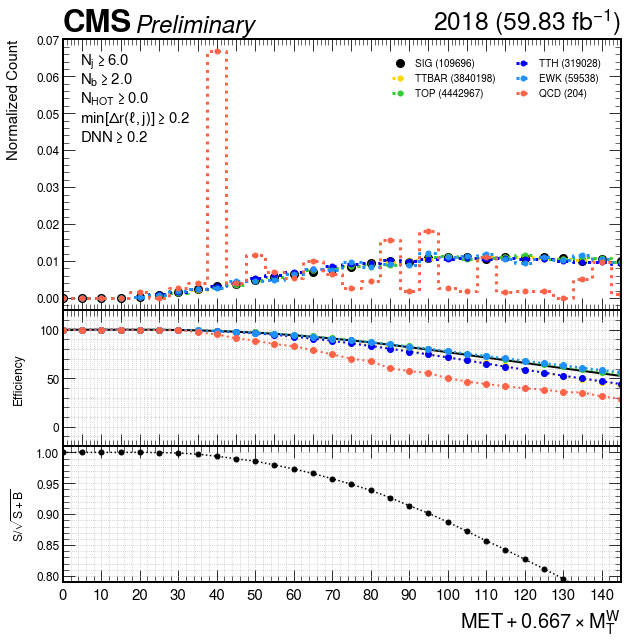

In [14]:
hColor = {
    "TOP": "limegreen",
    "QCD": "tomato",
    "EWK": "dodgerblue",
    "TTBAR": "gold",
    "TTH": "blue"
}

plt.style.use( hep.style.CMS )
figure, subplots = plt.subplots( 3, 1, gridspec_kw = { "height_ratios": [2,1,1], "hspace": 0. }, figsize = (10,10) )

hep.cms.text( "Preliminary", fontsize = 24, ax = subplots[0] )
hep.cms.lumitext( "{} {}".format( year, lumitext[ year ] ), ax = subplots[0] )

for g in hist_tot:
    if g in [ "TOTAL DATA", "TOTAL BKG" ]: continue
    if "SIG" in g:
        subplots[0].plot(
            hist_tot[ g ][1][:-1],
            hist_tot[ g ][0],
            linestyle = "", markersize = 8, marker = "o", color = "k",
            label = "{} ({})".format( g.replace( "TOTAL ", "" ), len( rDF_tot[g] ) ),
        )
        subplots[1].plot(
            vBins[ vPlot.value ],
            efficiency[ g ],
            linewidth = 2, color = "k",
        )
    else:
        subplots[0].step(
           vBins[ vPlot.value ][:-1],
            hist_tot[ g ][0],
            linewidth = 3, linestyle = ":", marker = "o", markersize = 5, where = "mid",
            color = hColor[ g.replace( "TOTAL ", "" ) ],
            label = "{} ({})".format( g.replace( "TOTAL ", "" ), len( rDF_tot[g] ) ),
        )
        subplots[1].plot(
            vBins[ vPlot.value ],
            efficiency[ g ],
            color = hColor[ g.replace( "TOTAL ", "" ) ],
            linewidth = 2, linestyle = ":", marker = "o"
        )
    
subplots[2].plot(
    vBins[ vPlot.value ][:-1],
    sensitivity,
    linestyle = ":", color = "k", marker = "o", markersize = 5
)
    
subplots[0].legend( loc = 1, fontsize = 10, ncol = 2, borderpad = 1.5 )
subplots[0].tick_params( axis = "y", labelsize = 12 )
subplots[0].set_xticks( vBins[ vPlot.value ] )
subplots[0].set_xlim( vBins[ vPlot.value ][0], vBins[ vPlot.value ][-2] )
subplots[0].set_xticklabels([])
subplots[0].set_ylabel( "Normalized Count", ha = "right", y = 1.0, fontsize = 15, labelpad = 15 )
subplots[0].annotate( r"$N_j\geq$" + str( cuts[ "NJets_JetSubCalc" ] ), ( 0.03, 0.95 ), xycoords = "axes fraction", va = "top", ha = "left", fontsize = 15 )
subplots[0].annotate( r"$N_b\geq$" + str( cuts[ "NJetsCSV_JetSubCalc" ] ), ( 0.03, 0.88 ), xycoords = "axes fraction", va = "top", ha = "left", fontsize = 15 )
subplots[0].annotate( r"$N_{HOT}\geq$" + str( cuts[ "NresolvedTops1pFake" ] ), ( 0.03, 0.81 ), xycoords = "axes fraction", va = "top", ha = "left", fontsize = 15 )
subplots[0].annotate( r"$min[\Delta r(\ell,j)]\geq$" + str( cuts[ "minDR_lepJet" ] ), ( 0.03, 0.74 ), xycoords = "axes fraction", va = "top", ha = "left", fontsize = 15 )
subplots[0].annotate( r"$DNN\geq$" + str( cuts[ "DNN_1to40_3t" ] ), ( 0.03, 0.67 ), xycoords = "axes fraction", va = "top", ha = "left", fontsize = 15 )
subplots[1].set_ylim( -20, 120 )
subplots[1].grid( which = "both" )
subplots[1].tick_params( axis = "y", labelsize = 12 )
subplots[1].set_xticks( vBins[ vPlot.value ] )
subplots[1].set_xlim( vBins[ vPlot.value ][0], vBins[ vPlot.value ][-2] )
subplots[1].set_xticklabels([])
subplots[1].set_ylabel( "Efficiency", ha = "center", y = 0.5, fontsize = 12, labelpad = 15 )
subplots[2].set_ylim( 0., 1.1 )
subplots[2].set_ylim( 0.79, 1.01 )
subplots[2].grid( which = "both" )
subplots[2].tick_params( axis = "y", labelsize = 12 )
subplots[2].set_xticks( vBins[ vPlot.value ][::2] )
subplots[2].set_xlim( vBins[ vPlot.value ][0], vBins[ vPlot.value ][-2] )
subplots[2].tick_params( axis = "x", labelsize = 15 )
if vPlot.value == "MTW_MET":
    subplots[2].set_xlabel( r"$MET + {} \times M_T^W$".format( scaleMTW ), ha = "right", x = 1.0, fontsize = 20, labelpad = 5 )
else:
    subplots[2].set_xlabel( vPlot.value, ha = "right", x = 1.0, fontsize = 20, labelpad = 5 )
subplots[2].set_ylabel( "$S/\sqrt{S+B}$", ha = "center", y = 0.5, fontsize = 12, labelpad = 9 )

plt.show()